# Heart Disease Model Evaluation

This notebook performs detailed evaluation of the machine learning models developed for heart disease classification.

## Objectives

- Evaluate the selected model beyond basic accuracy
- Analyze the confusion matrix and classification performance
- Examine precision, recall, F1 score, and ROC-AUC
- Analyze prediction thresholds
- Evaluate model calibration
- Interpret important features influencing predictions
- Identify model limitations and potential sources of error

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/heart_disease_eda.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (303, 14)


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["heart_disease"])
y = df["heart_disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training set: (242, 13)
Testing set: (61, 13)
Training targets: (242,)
Testing targets: (61,)


In [3]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numerical_features) + len(categorical_features))

Numerical features: 6
Categorical features: 7
Total features: 13


In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [5]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [6]:
y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))
print("First 5 predicted classes:", y_pred[:5])
print("First 5 predicted probabilities:", y_prob[:5])

Predictions generated successfully!
Number of predictions: 61
First 5 predicted classes: [0 1 0 0 0]
First 5 predicted probabilities: [0.21724573 0.58128632 0.02410892 0.0369686  0.3337398 ]


In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Confusion Matrix:
[[27  6]
 [ 2 26]]

True Negatives: 27
False Positives: 6
False Negatives: 2
True Positives: 26


In [8]:
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Sensitivity (Recall): 0.9286
Specificity: 0.8182


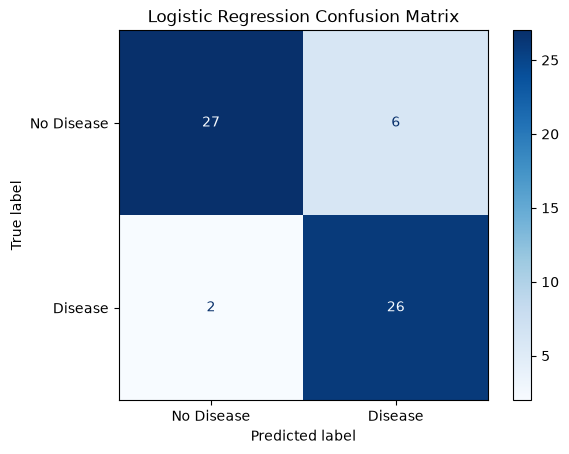

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")
print(f"ROC-AUC:     {roc_auc:.4f}")
print(f"Specificity: {specificity:.4f}")

Accuracy:    0.8689
Precision:   0.8125
Recall:      0.9286
F1 Score:    0.8667
ROC-AUC:     0.9578
Specificity: 0.8182


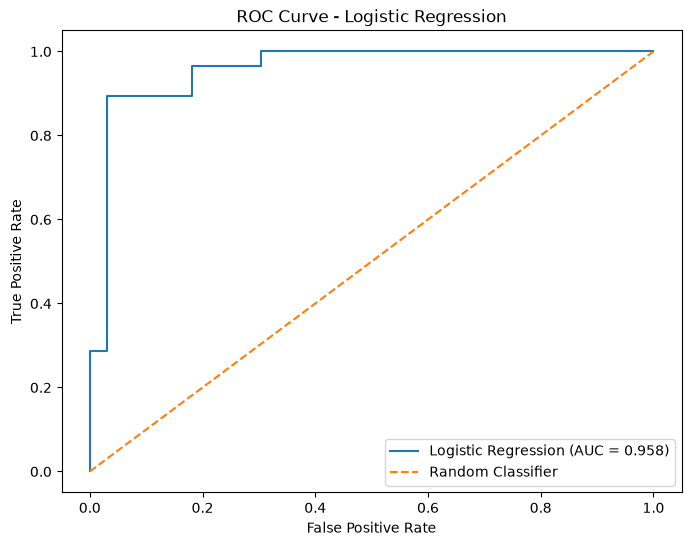

In [11]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

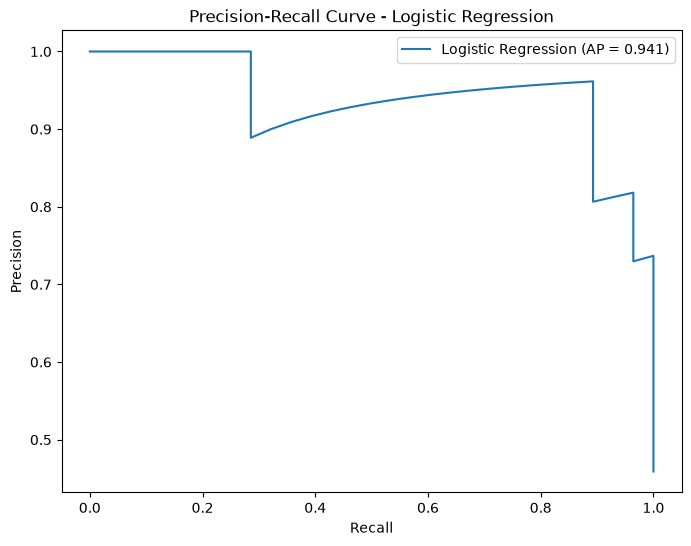

Average Precision Score: 0.9408


In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test, y_prob
)

average_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"Logistic Regression (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.show()

print(f"Average Precision Score: {average_precision:.4f}")

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    threshold_predictions = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_predictions),
        "Recall": recall_score(y_test, threshold_predictions),
        "F1 Score": f1_score(y_test, threshold_predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.3,0.7297,0.9643,0.8308
1,0.4,0.7941,0.9643,0.8710
2,0.5,0.8125,0.9286,0.8667
3,0.6,0.8929,0.8929,0.8929
4,0.7,0.9259,0.8929,0.9091


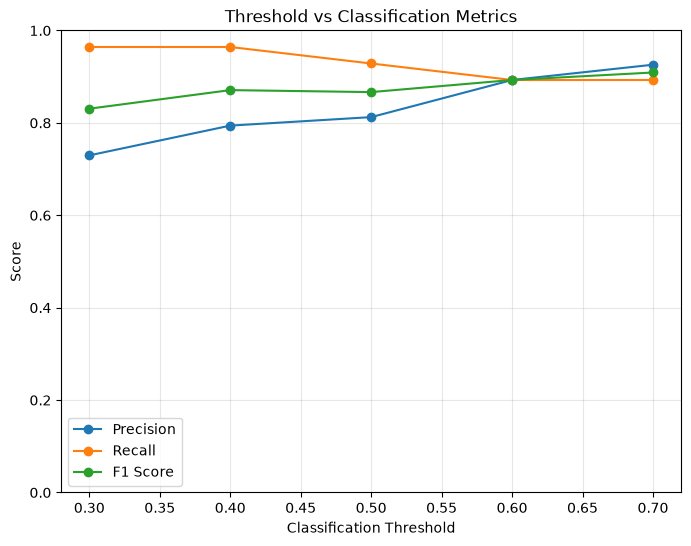

In [14]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Classification Metrics")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

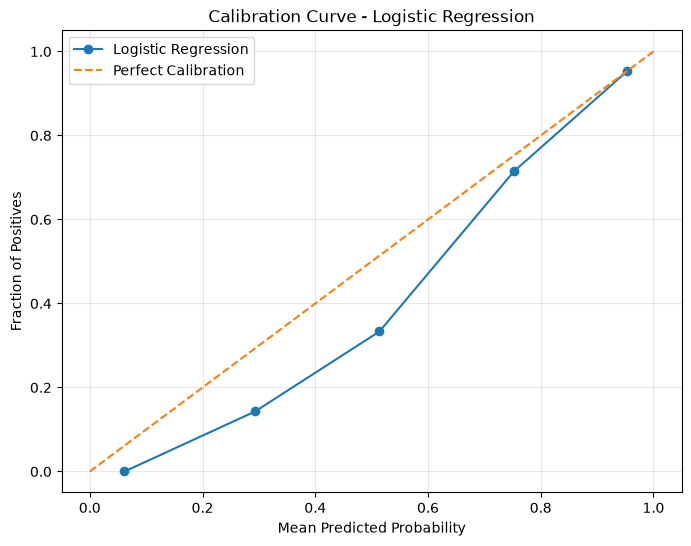

Brier Score: 0.0851


In [15]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=5,
    strategy="uniform"
)

brier_score = brier_score_loss(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Brier Score: {brier_score:.4f}")

In [16]:
feature_names = logistic_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of features after preprocessing:", len(feature_names))
print("\nFeatures used by the model:")

for feature in feature_names:
    print(feature)

Number of features after preprocessing: 25

Features used by the model:
num__age
num__trestbps
num__chol
num__thalach
num__oldpeak
num__ca
cat__sex_0.0
cat__sex_1.0
cat__cp_1.0
cat__cp_2.0
cat__cp_3.0
cat__cp_4.0
cat__fbs_0.0
cat__fbs_1.0
cat__restecg_0.0
cat__restecg_1.0
cat__restecg_2.0
cat__exang_0.0
cat__exang_1.0
cat__slope_1.0
cat__slope_2.0
cat__slope_3.0
cat__thal_3.0
cat__thal_6.0
cat__thal_7.0


In [17]:
coefficients = logistic_pipeline.named_steps[
    "model"
].coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficient_df.head(10).round(4)

,Feature,Coefficient,Absolute Coefficient
5,num__ca,1.1260,1.1260
11,cat__cp_4.0,0.9687,0.9687
24,cat__thal_7.0,0.8014,0.8014
6,cat__sex_0.0,-0.7226,0.7226
7,cat__sex_1.0,0.7214,0.7214
8,cat__cp_1.0,-0.6492,0.6492
20,cat__slope_2.0,0.6092,0.6092
22,cat__thal_3.0,-0.5615,0.5615
19,cat__slope_1.0,-0.4892,0.4892
10,cat__cp_3.0,-0.4784,0.4784


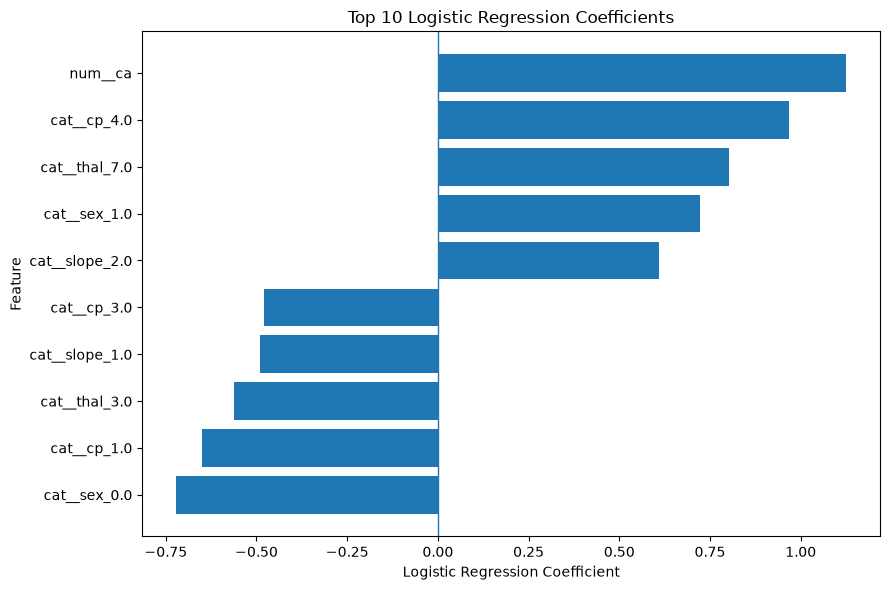

In [18]:
top_features = coefficient_df.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Logistic Regression Coefficients")

plt.tight_layout()
plt.show()

In [19]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = y_pred
error_analysis["Probability"] = y_prob

misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print("Total misclassified cases:", len(misclassified))

misclassified[
    ["Actual", "Predicted", "Probability"]
].sort_values("Probability").round(4)

Total misclassified cases: 8


,Actual,Predicted,Probability
66,1,0,0.2729
172,1,0,0.4521
287,0,1,0.5552
196,0,1,0.5602
271,0,1,0.5813
179,0,1,0.6907
33,0,1,0.7341
92,0,1,0.9766


In [20]:
misclassified["Error Type"] = np.where(
    (misclassified["Actual"] == 1) &
    (misclassified["Predicted"] == 0),
    "False Negative",
    "False Positive"
)

misclassified[
    ["Actual", "Predicted", "Probability", "Error Type"]
].sort_values("Probability").round(4)

,Actual,Predicted,Probability,Error Type
66,1,0,0.2729,False Negative
172,1,0,0.4521,False Negative
287,0,1,0.5552,False Positive
196,0,1,0.5602,False Positive
271,0,1,0.5813,False Positive
179,0,1,0.6907,False Positive
33,0,1,0.7341,False Positive
92,0,1,0.9766,False Positive


In [21]:
false_negatives = misclassified[
    misclassified["Error Type"] == "False Negative"
]

false_negatives.round(4)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual,Predicted,Probability,Error Type
66,60,1,3,140,185,0,2,155,0,3.0,2,0.0,3.0,1,0,0.2729,False Negative
172,59,0,4,174,249,0,0,143,1,0.0,2,0.0,3.0,1,0,0.4521,False Negative


In [22]:
uncertainty_analysis = error_analysis.copy()

uncertainty_analysis["Distance from 0.5"] = (
    uncertainty_analysis["Probability"] - 0.5
).abs()

most_uncertain = uncertainty_analysis.sort_values(
    "Distance from 0.5"
).head(10)

most_uncertain[
    ["Actual", "Predicted", "Probability", "Distance from 0.5"]
].round(4)

,Actual,Predicted,Probability,Distance from 0.5
292,1,1,0.5265,0.0265
172,1,0,0.4521,0.0479
287,0,1,0.5552,0.0552
196,0,1,0.5602,0.0602
271,0,1,0.5813,0.0813
131,0,0,0.4077,0.0923
115,0,0,0.3978,0.1022
197,0,0,0.3713,0.1287
67,0,0,0.3337,0.1663
179,0,1,0.6907,0.1907


In [23]:
confidence_categories = pd.cut(
    uncertainty_analysis["Distance from 0.5"],
    bins=[0, 0.1, 0.2, 0.3, 0.5],
    labels=[
        "Very Uncertain",
        "Uncertain",
        "Moderately Confident",
        "Highly Confident"
    ],
    include_lowest=True
)

confidence_counts = confidence_categories.value_counts().sort_index()

print("Prediction Confidence Distribution:")
print(confidence_counts)

Prediction Confidence Distribution:
Distance from 0.5
Very Uncertain           6
Uncertain                4
Moderately Confident    10
Highly Confident        41
Name: count, dtype: int64


In [24]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=["No Disease", "Disease"]
)

print(report)

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-validation ROC-AUC scores:")
print(cv_scores)

print(f"\nMean CV ROC-AUC: {cv_scores.mean():.4f}")
print(f"CV Standard Deviation: {cv_scores.std():.4f}")

Cross-validation ROC-AUC scores:
[0.9180602  0.93434343 0.88986014 0.91083916 0.87937063]

Mean CV ROC-AUC: 0.9065
CV Standard Deviation: 0.0197


## Model Evaluation Summary

The Logistic Regression model demonstrated strong classification performance on the heart disease dataset.

### Key Results

- Test Accuracy: 86.89%
- Precision (Disease): 81.25%
- Recall / Sensitivity (Disease): 92.86%
- Specificity: 81.82%
- F1 Score: 86.67%
- Test ROC-AUC: 95.78%
- Average Precision: approximately 94.1%
- Brier Score: 0.0851
- Mean 5-Fold CV ROC-AUC: 90.65%
- CV Standard Deviation: 1.97%

The confusion matrix contained 27 true negatives, 26 true positives, 6 false positives, and 2 false negatives.

Threshold analysis demonstrated the trade-off between precision and recall. These threshold results were treated as exploratory and were not used to tune the final decision threshold on the test set.

Error analysis showed that several incorrect predictions occurred near the 0.50 classification threshold, although the model also produced some confident errors. Therefore, predicted probabilities should not be interpreted as guarantees.

Logistic Regression coefficients were examined to understand which transformed features influenced predictions. These coefficients represent associations learned from this dataset and should not be interpreted as causal medical relationships.

### Limitations

- The dataset contains only 303 records.
- The test set contains only 61 records.
- The dataset may not represent modern or diverse clinical populations.
- The fixed test split was examined during model comparison and detailed exploratory evaluation, so future work should use an untouched external validation dataset or nested cross-validation for stronger performance estimates.
- Probability calibration was evaluated on a relatively small test sample.
- Model predictions are not clinically validated and must not be used for diagnosis or treatment decisions.

This model will be used only as an educational machine learning component within the Clinical Intelligence Assistant.